# 📘 Table of Contents

1. [**Business Context & Objective**](#business-context--objective)  
2. [**Data Overview**](#data-overview)  
3. [**Exploratory Data Analysis (EDA)**](#exploratory-data-analysis-eda)  
4. [**Data Pre-processing**](#data-pre-processing)  
5. [**Model 1: Basic CNN (Grayscale)**](#model-1-basic-cnn-grayscale)  
6. [**Model 2: Basic CNN (RGB)**](#model-2-basic-cnn-rgb)  
7. [**Model 3: VGG16 (Transfer Learning)**](#model-3-vgg16-transfer-learning)  
8. [**Model 4: VGG16 + FFNN**](#model-4-vgg16--ffnn)  
9. [**Model 5: VGG16 + Data Augmentation**](#model-5-vgg16--data-augmentation)  
10. [**Model 6: VGG16 + FFNN + Data Augmentation (Final Model)**](#model-6-vgg16--ffnn--data-augmentation-final-model)  
11. [**Model Performance Comparison**](#model-performance-comparison)  
12. [**Final Model Selection**](#final-model-selection)  
13. [**Actionable Insights & Recommendations**](#actionable-insights--recommendations)  
14. [**Conclusion**](#conclusion)


## [**Business Context & Objective**](#business-context--objective)  

**Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

**Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## [**Data Overview**](#data-overview)  

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

**Installing and Importing the Necessary Libraries**

In [92]:
import tensorflow as tf

In [93]:

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.1


In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas for Data Manipulation and Analysis
import seaborn as sns
import matplotlib.image as mpimg                                                                 
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                                       # Importing the VGG16 model for Transfer Learning   

# Display images using OpenCV
# from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 
from tensorflow.keras.layers import Dense,Flatten,Input,GlobalAveragePooling2D
from tensorflow.keras import losses,optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications.vgg16 import preprocess_input
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
tf.keras.utils.set_random_seed(812)

## [**Exploratory Data Analysis (EDA)**](#exploratory-data-analysis-eda)  


**Loading the data**

In [96]:
#Loading the images from the images_proj.npy file
rgb_images = np.load('images_proj.npy')

#Loading the labels from the labels_proj.npy file
labels = pd.read_csv('Labels_proj.csv')

In [97]:
#shapes of images and labels
print("Shape of images:", rgb_images.shape)
print("Shape of labels:", labels.shape)

Shape of images: (631, 200, 200, 3)
Shape of labels: (631, 1)


There are total 631 images with size of 200 X 200 X3, each having 3 channels

All the images has **Labels** which dictates whether *the person is wearing a Helmet or not*

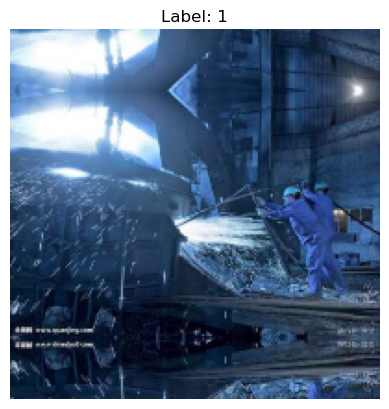

In [98]:
n=5
plt.imshow(rgb_images[n])
plt.title(f"Label: {labels['Label'][n]}")
plt.axis('off')
plt.show()

Creating a function to print random images

In [99]:
def plot_images(images, labels):
    keys = dict(labels['Label'])
    rows = 3
    cols = 4
    fig = plt.figure(figsize=(10, 8))

    for i in range(cols):
        for j in range(rows):
            index = np.random.randint(0, len(images))
            ax = fig.add_subplot(rows, cols, i * rows + j + 1)
            ax.imshow(images[index])
            ax.set_title(f"Label: {labels['Label'][index]}")
            # ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Plot random images from each of the classes and print their corresponding labels.

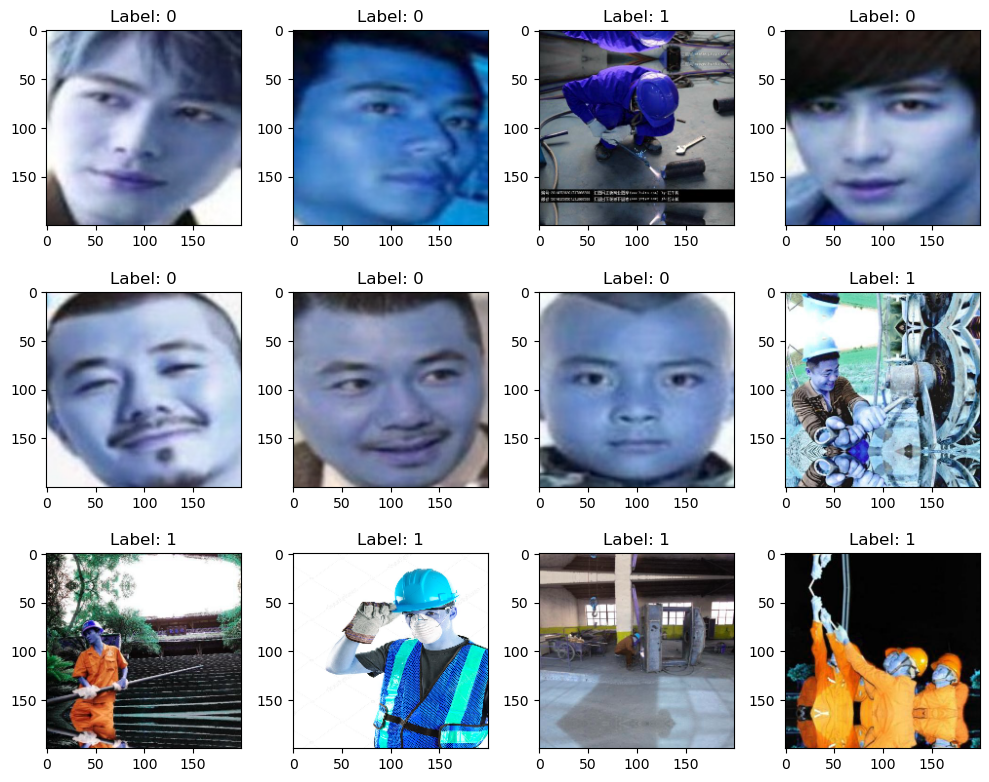

In [100]:
plot_images(rgb_images, labels)

**Checking for class imbalance**


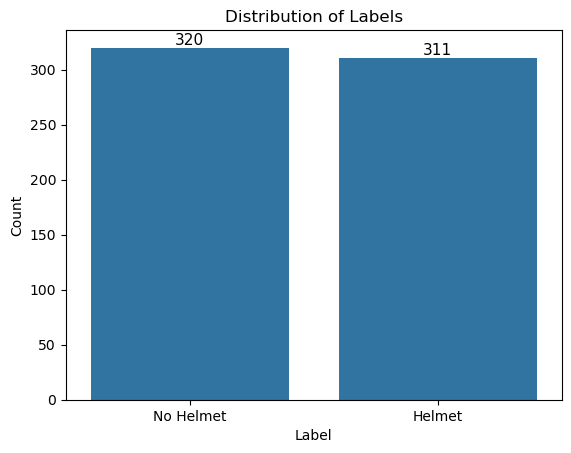

In [101]:
sns.countplot(x='Label', data=labels)
plt.title('Distribution of Labels')
plt.xticks([0, 1], ['No Helmet', 'Helmet'])
#adding number of counts on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                       textcoords='offset points')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

**Key Observation**

- Based on the above figure we can see the data is balanced
    - No Helmet - 320
    - Helmet - 311

- There are two types of images, one with having Helmet and other No Helmet

## [**Data Pre-processing**](#data-pre-processing)

Creating a function to display original and processed version together side-by-side.

**Inputs**
- original_image - Original Image that is being processed
- processed_image - Processed Image
- grayscale - An optional parameter it will display the image in grayscale

**Output**
- The original and processed image to be visible side-by-side

In [102]:
def grid_plot(original_image, processed_image, grayscale=False):
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    axes[0].imshow(original_image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    if grayscale:
        axes[1].imshow(processed_image, cmap='gray')
    else:
        axes[1].imshow(processed_image)
    axes[1].set_title("Processed Image")
    axes[1].axis('off')
    plt.show()

**Converting images to grayscale**

In [103]:
#Converting an image to grayscale

gray_image = []

for i in range(len(rgb_images)):
    gray = cv2.cvtColor(rgb_images[i], cv2.COLOR_BGR2GRAY)
    gray_image.append(gray)

In [104]:
#Showing random original and grayscale images side-by-side

for i in range(random.randint(0,5)):    
    grid_plot(rgb_images[i], gray_image[i], grayscale=True)

- Based on the above we can see that the color images have been changed to grayscale
- As the requirement is to identify whether a person is wearing a Helmet it would be better to use color images as it will have a better compositions
- Will try with both color and grayscale to see which one performs better

**Grayscale Images Training and Testing**

### Splitting the dataset



In [105]:
#Checking the size of grayscale images
gray_image = np.array(gray_image)
print("Shape of grayscale images:", gray_image.shape)

print("Shape of one graysclae image:" ,gray_image[0].shape)

Shape of grayscale images: (631, 200, 200)
Shape of one graysclae image: (200, 200)


We are going to split the dataset into 
- Training (80%)
- Validation (10%)
- Testing (10%)

In [106]:
RANDOM_STATE = 42

#### Splitting RGB Images

In [107]:
#Splitting the data into training (80%) and first validation + testing (20%)
X_train_rgb_original, X_temp_rgb_original, y_train_rgb_original, y_temp_rgb_original= train_test_split(np.array(rgb_images), labels['Label'], test_size=0.2, random_state=RANDOM_STATE, stratify=labels['Label'])
#Splitting the temp data into validation (10%) and testing (10%)
X_val_rgb_original, X_test_rgb_original, y_val_rgb_original, y_test_rgb_original = train_test_split(X_temp_rgb_original, y_temp_rgb_original, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_rgb_original)

#### Splitting GrayScale Images

In [108]:
#Splitting the data into training (80%) and first validation + testing (20%)
X_train_gray, X_temp_gray, y_train, y_temp = train_test_split(np.array(gray_image), labels['Label'], test_size=0.2, random_state=RANDOM_STATE, stratify=labels['Label'])
#Splitting the temp data into validation (10%) and testing (10%)
X_val_gray, X_test_gray, y_val, y_test = train_test_split(X_temp_gray, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

### Data Normalization

Now we are going to do **Normalization** which helps in 
- Training faster and reduces chances of getting stuck at a local option
- Weight decay and estimation can be done more conveniently
- It avoids in Vanishing/Exploding gradient problem

In [109]:
X_train_gray.shape[0]


504

In [110]:
#Reshaping the data to add channel dimension and also normalizing the pixel values to the range [0, 1] for better convergence only for training and validation sets
X_train_gray = X_train_gray.astype('float32')/ 255.0
X_val_gray = X_val_gray.astype('float32') / 255.0
X_test_gray = X_test_gray.astype('float32') / 255.0

In [111]:
X_train_rgb = X_train_rgb_original.astype('float32')/ 255.0
X_val_rgb= X_val_rgb_original.astype('float32') / 255.0
X_test_rgb = X_test_rgb_original.astype('float32') / 255.0

In [112]:
X_train_rgb

array([[[[0.38039216, 0.35686275, 0.36078432],
         [0.3647059 , 0.34509805, 0.34901962],
         [0.23137255, 0.21176471, 0.21176471],
         ...,
         [0.8039216 , 0.8509804 , 0.85882354],
         [0.83137256, 0.8784314 , 0.88235295],
         [0.88235295, 0.9372549 , 0.9372549 ]],

        [[0.4117647 , 0.38431373, 0.39215687],
         [0.3647059 , 0.34509805, 0.34901962],
         [0.21960784, 0.2       , 0.20392157],
         ...,
         [0.24705882, 0.28235295, 0.31764707],
         [0.23921569, 0.28235295, 0.31764707],
         [0.3019608 , 0.34117648, 0.3764706 ]],

        [[0.39215687, 0.37254903, 0.37254903],
         [0.3764706 , 0.35686275, 0.35686275],
         [0.21568628, 0.19607843, 0.2       ],
         ...,
         [0.15294118, 0.1882353 , 0.24313726],
         [0.16078432, 0.19215687, 0.2509804 ],
         [0.15686275, 0.19215687, 0.2509804 ]],

        ...,

        [[0.4627451 , 0.48235294, 0.48235294],
         [0.24313726, 0.2627451 , 0.2627451 ]

In [113]:
print("X_train_gray:", X_train_gray.shape)
print("X_val_gray:  ", X_val_gray.shape)
print("X_test_gray: ", X_test_gray.shape)

print("X_train_g min/max:", X_train_gray.min(), X_train_gray.max())

X_train_gray: (504, 200, 200)
X_val_gray:   (63, 200, 200)
X_test_gray:  (64, 200, 200)
X_train_g min/max: 0.0 1.0


In [114]:
X_train_gray

array([[[0.36078432, 0.34901962, 0.21568628, ..., 0.84705883,
         0.8745098 , 0.92941177],
        [0.3882353 , 0.34901962, 0.20392157, ..., 0.2901961 ,
         0.28627452, 0.34901962],
        [0.3764706 , 0.36078432, 0.2       , ..., 0.2       ,
         0.20784314, 0.20392157],
        ...,
        [0.47843137, 0.25882354, 0.34901962, ..., 0.22745098,
         0.23529412, 0.2509804 ],
        [0.3372549 , 0.24313726, 0.3647059 , ..., 0.2       ,
         0.21960784, 0.30980393],
        [0.45490196, 0.27058825, 0.43529412, ..., 0.19607843,
         0.21960784, 0.34117648]],

       [[0.4       , 0.4       , 0.40392157, ..., 0.84313726,
         0.8392157 , 0.8392157 ],
        [0.39607844, 0.4       , 0.40392157, ..., 0.84313726,
         0.8392157 , 0.8352941 ],
        [0.39607844, 0.39607844, 0.4       , ..., 0.8392157 ,
         0.8352941 , 0.8352941 ],
        ...,
        [0.6156863 , 0.6156863 , 0.62352943, ..., 0.5882353 ,
         0.5764706 , 0.5686275 ],
        [0.6

After doing normalization

|Set|#of Images|Height|Width|
|---|---|---|---|
|Training|504|200|200|
|Validation|63|200|200|
|Testing|64|200|200|

RGB already has channel shape=(504, 200, 200, **3**), dtype=float32) but GrayScale is missing shape=(504, 200, 200), dtype=float32) so we need to add the channel to it.

In [115]:
#adding channel dimension to grayscale images
X_train_g = X_train_gray[..., np.newaxis]
X_val_g   = X_val_gray[..., np.newaxis]
X_test_g  = X_test_gray[..., np.newaxis]

In [116]:
print("After doing normalization", X_train_g.shape)
print("After doing normalization", X_val_g.shape)
print("After doing normalization", X_test_g.shape)

print("X_train_g min/max:", X_train_g.min(), X_train_g.max())

After doing normalization (504, 200, 200, 1)
After doing normalization (63, 200, 200, 1)
After doing normalization (64, 200, 200, 1)
X_train_g min/max: 0.0 1.0


After doing Normalization below is the stats

|DataSet|# of Rows|Height|Width|Channel|
|---|---|---|---|---|
|Training|504|200|200|1|
|Validation|504|200|200|1|
|Testing|504|200|200|1|

The min and max value is between **0.0 to 1.0**

In [117]:
print("X_train_rgb:", X_train_rgb.shape)
print("X_val_rgb:  ", X_val_rgb.shape)
print("X_test_rgb: ", X_test_rgb.shape)

print("X_train_g min/max:", X_train_rgb.min(), X_train_rgb.max())

X_train_rgb: (504, 200, 200, 3)
X_val_rgb:   (63, 200, 200, 3)
X_test_rgb:  (64, 200, 200, 3)
X_train_g min/max: 0.0 1.0


After doing Normalization below is the stats for RGB

|DataSet|# of Rows|Height|Width|Channel|
|---|---|---|---|---|
|Training|504|200|200|1|
|Validation|504|200|200|1|
|Testing|504|200|200|1|

The min and max value is between **0.0 to 1.0**

Encode labels to binary (0/1)

In [118]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [119]:
y_train

83     1
202    1
176    1
404    0
427    0
      ..
438    0
11     1
617    0
511    0
233    1
Name: Label, Length: 504, dtype: int64

In [120]:
y_train_enc 

array([1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,

## Model Evaluation Criterion

For the model evaluation we use accuracy, precision, recall and F1-score. Since this is safety-critical problem, we aim for high accuracy and recall to minimize risk and making a safer working environment. 

**Utility Functions**

In [121]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target, dataset, batch_size=2):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors,batch_size=batch_size).reshape(-1)>0.5

    # target = target.to_numpy().reshape(-1)
    target = target.reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Dataset": dataset,"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [122]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    # target = target.to_numpy().reshape(-1)
    target = target.reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [123]:
def generate_table_for_md(df):
    """
    Function to generate markdown table from a dataframe

    df: dataframe
    """

    # Generating the markdown table
    md_table = df.to_markdown(index=False)
    return md_table

## [**Model 1: Basic CNN (Grayscale)**](#model-1-basic-cnn-grayscale)  

In [124]:
model_gray = Sequential() # Initializing the Sequential model for Grayscale images
model_gray.add(Input(shape=(200,200,1)))  # Adding input layer
model_gray.add(Conv2D(32, (3, 3), activation='relu', padding='same')) # Adding first convolutional layer
model_gray.add(MaxPooling2D((2, 2))) # Adding first max pooling layer
model_gray.add(Conv2D(64, (3, 3), activation='relu', padding='same')) # Adding second convolutional layer
model_gray.add(MaxPooling2D((2, 2))) # Adding second max pooling layer
model_gray.add(Conv2D(128, (3, 3), activation='relu', padding='same')) # Adding third convolutional layer
model_gray.add(MaxPooling2D((2, 2))) # Adding third max pooling layer
model_gray.add(GlobalAveragePooling2D()) # Adding Global Average Pooling layer
model_gray.add(Dropout(0.4)) # Adding Dropout layer to prevent overfitting
model_gray.add(Dense(64, activation='relu')) # Adding fully connected layer
model_gray.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification



In [125]:
#Intializing the Adam optimizer and compiling the model with categorical crossentropy loss function and accuracy metric
adam = optimizers.Adam()
model_gray.compile(optimizer=adam, loss=losses.binary_crossentropy, metrics=['accuracy'])

In [126]:
#Displaying the model summary
model_gray.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,993 (394.50 KB)

 Trainable params: 100,993 (394.50 KB)

 Non-trainable params: 0 (0.00 B)

So based on the above the CNN consists of below layers
- Convulation Layer 
- Max Pooling Layer
- Convulation Layer
- Max Pooling Layer
- Convulation Layer
- Max Pooling Layer
- Global Average Pooling
- Dropout
- Full Connected Layer
- Final Output Layer

So there are total of **100,993** and as we are training this CNN from the scratch all the parameters need to be trained. There are **no Non-trainable Params**. 

In [127]:
#Fitting the model on Grayscale images
history_gray = model_gray.fit(X_train_g,y_train_enc,validation_data=(X_val_g, y_val_enc),epochs=20, batch_size=32)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.4722 - loss: 0.6777 - val_accuracy: 0.4921 - val_loss: 0.6270
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.6111 - loss: 0.5596 - val_accuracy: 0.4921 - val_loss: 0.4593
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8849 - loss: 0.3522 - val_accuracy: 0.9683 - val_loss: 0.1945
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.9702 - loss: 0.1375 - val_accuracy: 0.9683 - val_loss: 0.1164
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9683 - loss: 0.0999 - val_accuracy: 0.9683 - val_loss: 0.0560
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9901 - loss: 0.0513 - val_accuracy: 0.9683 - val_loss: 0.0787
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9881 - loss: 0.0470 - val_accuracy: 0.9683 - val_loss: 0.1052
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9940 - loss: 0.0317 - val_accuracy: 0.9683 - 

### Vizualizing the predictions

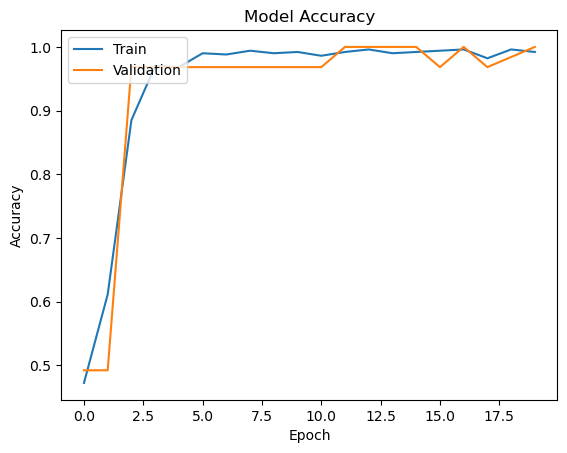

In [128]:
plt.plot(history_gray.history['accuracy']) # Plotting training & validation accuracy values
plt.plot(history_gray.history['val_accuracy']) # Plotting training & validation accuracy values
plt.title('Model Accuracy') 
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

As we can see based on the above plot, the model seems to be performing well on both training and validation sets without significant overfitting. The accuracy is improving consistently over each epochs. 

In [129]:
lst_gray = []
model_gray_train_perf = model_performance_classification(model_gray, X_train_g,y_train_enc, dataset='Training')

print("Train performance metrics")
print(model_gray_train_perf)

print("Validation performance metrics")
model_gray_val_perf = model_performance_classification(model_gray, X_val_g, y_val_enc, dataset='Validation')
print(model_gray_val_perf)

print("Test performance metrics")
model_gray_test_perf = model_performance_classification(model_gray, X_test_g, y_test_enc, dataset='Testing')
print(model_gray_test_perf)


lst_gray.append(model_gray_train_perf)
lst_gray.append(model_gray_val_perf)
lst_gray.append(model_gray_test_perf)

md_table = generate_table_for_md(pd.concat(lst_gray, ignore_index=True))
print(md_table)

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train performance metrics
    Dataset  Accuracy    Recall  Precision  F1 Score
0  Training  0.998016  0.998016   0.998024  0.998016
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.998016 | 0.998016 |    0.998024 |   0.998016 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |


👉 Observation

| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.998016 | 0.998016 |    0.998024 |   0.998016 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |


So based on above we can see that there is a good accuracy (99.6% in Training and 100% in Validation and Testing )  on all the three dataset. 



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 


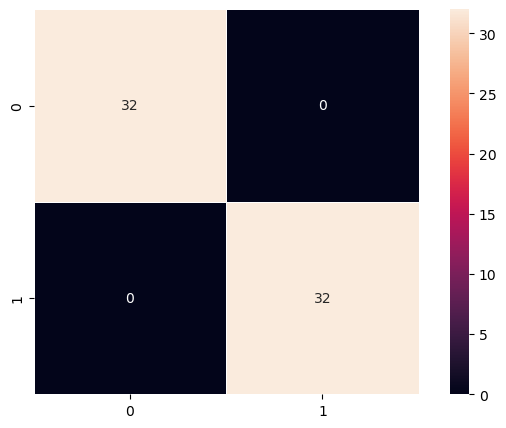

In [130]:
plot_confusion_matrix(model_gray, X_test_g, y_test_enc)

Based on the above confusion matrix, the model seems to be performing well in classifying both classes. 

Model was able to predict 100% for both positive and negative values.

So it seems that the model has achieved high accuracy on the test set, indicating that it generalizes well to unseen data.

🔭 Final Observation:

The Gray Model has performed really well in all the Training, Validation and Testing dataset. 

This can be due to multiple reasons as the test and training dataset are small the CNN was able to get the prediction correctly.

As we are trying to find the Helmet vs no-Helmet scenario, it may give a clear differentiation between the two images helping CNN to identify the images properly.

## [**Model 2: Basic CNN (RGB)**](#model-2-basic-cnn-rgb) 

As previous model we have created a model based on grayscale images. Lets see if we can use the RGB images itself to do the prediction. Even though we got 100% accuracy this might be more valid scenario as its easy to identify Helmet/no-Helmet in colored images.

In [131]:
model_rgb = Sequential()
model_rgb.add(Input(shape=(200,200,3)))  # Adding input layer
model_rgb.add(Conv2D(32, (3, 3), activation='relu', padding='same')) # Adding first convolutional layer
model_rgb.add(MaxPooling2D((2, 2))) # Adding first max pooling layer
model_rgb.add(Conv2D(64, (3, 3), activation='relu', padding='same')) # Adding second convolutional layer
model_rgb.add(MaxPooling2D((2, 2)))# Adding second max pooling layer
model_rgb.add(Conv2D(128, (3, 3), activation='relu', padding='same')) # Adding third convolutional layer
model_rgb.add(MaxPooling2D((2, 2))) # Adding third max pooling layer
model_rgb.add(GlobalAveragePooling2D()) # Adding Global Average Pooling layer
model_rgb.add(Dropout(0.4)) # Adding Dropout layer to prevent overfitting
model_rgb.add(Dense(64, activation='relu')) # Adding fully connected layer
model_rgb.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

In [132]:

model_rgb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [133]:
model_rgb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

So based on the above the CNN consists of below layers
- Convulation Layer 
- Max Pooling Layer
- Convulation Layer
- Max Pooling Layer
- Convulation Layer
- Max Pooling Layer
- Global Average Pooling
- Dropout
- Full Connected Layer
- Final Output Layer

So there are total of **304709** and as we are training this CNN from the scratch all the parameters need to be trained. There are **no Non-trainable Params**. There are **101,569** trainable paramaeters and **203,140** Optimizer params (Optimizer parameters that adams keeps it for itself, it cannot be trained).

In [134]:
#Fitting the model on RGB images
history_rgb = model_rgb.fit(X_train_rgb,y_train_enc,validation_data=(X_val_rgb, y_val_enc),epochs=20, batch_size=32)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.5853 - loss: 0.6608 - val_accuracy: 0.5556 - val_loss: 0.5908
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.8373 - loss: 0.4126 - val_accuracy: 0.9206 - val_loss: 0.2015
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9127 - loss: 0.2534 - val_accuracy: 0.9206 - val_loss: 0.1939
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9444 - loss: 0.1637 - val_accuracy: 1.0000 - val_loss: 0.0746
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9782 - loss: 0.0831 - val_accuracy: 0.9841 - val_loss: 0.0415
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9861 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 0.0118
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9901 - loss: 0.0375 - val_accuracy: 0.9683 - val_loss: 0.0480
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9782 - loss: 0.0596 - val_accuracy: 1.0

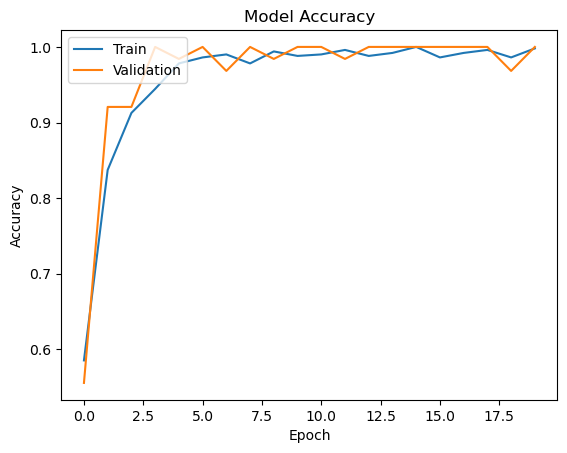

In [135]:
plt.plot(history_rgb.history['accuracy'])
plt.plot(history_rgb.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Visualization of Model Accuracy

As we can see from the above plot, the RGB model is also having the good performance on both training and validation sets. 

The training performance of RGB model is slightly lower than GrayScale due to the fact that in gray scale image there is less information (no colors) which leads to more quickly fitting the model. Whereas in RGB images include color information which results is more meaningful features, but it also introduces more complexity so training accuracy may be low. The color information plays a more important factor in real-world scenarios.

The training accuracy is getting better after each epochs. The validation accuracy also follow very closelly the training pattern. This suggest that the model is generalizing well.

👉Key Observations:
- The model shows better performance only within 20 epochs
- Both training and validation curves are showing same pattern
- Seems like model is generalizing well based on the curve for the training and validation
- Seems like model is not overfitting and also showing higher accuracy


So, will use RGB images for any further model evaluation.

In [136]:
model_rgb_train_perf = model_performance_classification(model_rgb, X_train_rgb,y_train_enc, dataset='Training')

print("Train performance metrics")
print(model_rgb_train_perf)


print("Validation performance metrics")
model_rgb_val_perf = model_performance_classification(model_rgb, X_val_rgb, y_val_enc, dataset='Validation')
print(model_rgb_val_perf)

print("Test performance metrics")
model_rgb_test_perf = model_performance_classification(model_rgb, X_test_rgb, y_test_enc, dataset='Testing')

print(model_rgb_test_perf)

lst_rgb = []
lst_rgb.append(model_rgb_train_perf)   
lst_rgb.append(model_rgb_val_perf)
lst_rgb.append(model_rgb_test_perf)
md_table = generate_table_for_md(pd.concat(lst_rgb, ignore_index=True))
print(md_table)

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train performance metrics
    Dataset  Accuracy    Recall  Precision  F1 Score
0  Training  0.994048  0.994048   0.994055  0.994047
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.994048 | 0.994048 |    0.994055 |   0.994047 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |


The model performance is shown below.

| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.994048 | 0.994048 |    0.994055 |   0.994047 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |

So as we can see there is better accuracy 99.4% on training and 100% on both validation and testing test. 

This is alomst similar performance as the GrayScale model depicted. The reason may be same as the grayscale model performance. 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 


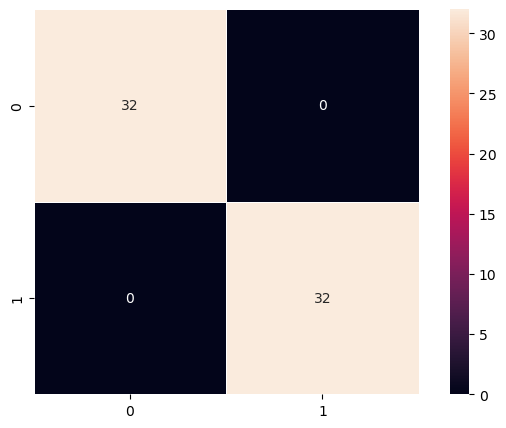

In [137]:
plot_confusion_matrix(model_rgb, X_test_rgb, y_test_enc)

👉Based on the above confusion matrix, RGB model is able to get all the prediction correctly without any delay in process i.e. it didn't take significantly more processing time than GrayScale model.

This model performs well for helmet/no-helmet detection. As the performance is good and also it's easier to identify the helmet/no-helmet in colored images which also helps in different types of lighting conditions.

So we should be using RGB images for the processing.

## [**Model 3: VGG16 (Transfer Learning)**](#model-3-vgg16-transfer-learning) 

In [138]:
tf.keras.backend.clear_session()

In [139]:
#Function to prepare images for VGG16 model
def prepare_for_vgg(arr):
    # arr_resized = np.array([cv2.resize(img, (224, 224)) for img in arr])
    # arr_resized=arr_resized.astype('float32')
    # return arr_resized
    return preprocess_input(arr) # Preprocessing input for VGG16 model i.e. to change from RGB to BGR 

In [140]:
#Preparing the data for VGG16 model
X_train_vgg = prepare_for_vgg(X_train_rgb_original)
X_val_vgg   = prepare_for_vgg(X_val_rgb_original)
X_test_vgg  = prepare_for_vgg(X_test_rgb_original)

print("VGG shapes:", X_train_vgg.shape, X_val_vgg.shape, X_test_vgg.shape)


VGG shapes: (504, 200, 200, 3) (63, 200, 200, 3) (64, 200, 200, 3)


In [141]:
def build_vgg_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3)) # Using VGG16 as base model
    base_model.trainable = False  # Freeze the base model

    model = Sequential() # Initializing the Sequential model
    model.add(base_model) # Adding the base model
    model.add(GlobalAveragePooling2D()) # Adding Global Average Pooling layer
    model.add(Dropout(0.5)) # Adding Dropout layer to prevent overfitting
    model.add(Dense(64, activation='relu')) # Adding fully connected layer
    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model, base_model

In [142]:
model_vgg, base_vgg = build_vgg_model() 
model_vgg.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

As we are using VGG model and we have the VGG layer as non-trainable, that's why once we build the entire model it looks like below
- VGG (Funtion)
- Global Average Pooling
- Dropout
- Dense
- Dense Output

So total there are 14,747,585 parameters out of which all the VGG parameters are non-trainable i.e. 14,714,688 and only trainable parameters are 32,897. This will provide computation benefits and the benefit that we are using already trained model and not training it from the scratch.

So based on the using

In [143]:
model_vgg.compile(optimizer = optimizers.Adam(learning_rate=1e-4), loss=losses.binary_crossentropy, metrics=['accuracy'])

cb_vgg = [
    callbacks.ModelCheckpoint('vgg16_best.keras', save_best_only=True, monitor='val_accuracy', mode='max'), # Save the best model based on validation accuracy
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), # Stop training if validation loss doesn't improve for 5 epochs
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7) # Reduce learning rate when a metric has stopped improving
]

In [144]:
history_vgg = model_vgg.fit(
    X_train_vgg, y_train_enc,
    validation_data=(X_val_vgg, y_val_enc),
    epochs=15,
    batch_size=2,
    callbacks=cb_vgg,
    verbose=2
)

Epoch 1/15
252/252 - 15s - 59ms/step - accuracy: 0.8056 - loss: 0.7575 - val_accuracy: 1.0000 - val_loss: 0.0066 - learning_rate: 1.0000e-04
Epoch 2/15
252/252 - 10s - 39ms/step - accuracy: 0.9405 - loss: 0.1750 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 3/15
252/252 - 10s - 39ms/step - accuracy: 0.9782 - loss: 0.0847 - val_accuracy: 1.0000 - val_loss: 0.0020 - learning_rate: 1.0000e-04
Epoch 4/15
252/252 - 10s - 39ms/step - accuracy: 0.9802 - loss: 0.0665 - val_accuracy: 1.0000 - val_loss: 1.8047e-04 - learning_rate: 1.0000e-04
Epoch 5/15
252/252 - 10s - 39ms/step - accuracy: 0.9980 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 1.6089e-04 - learning_rate: 1.0000e-04
Epoch 6/15
252/252 - 10s - 39ms/step - accuracy: 0.9861 - loss: 0.0512 - val_accuracy: 1.0000 - val_loss: 1.9756e-04 - learning_rate: 1.0000e-04
Epoch 7/15
252/252 - 10s - 38ms/step - accuracy: 0.9940 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 2.1016e-04 - learning_rate: 1.0000e-

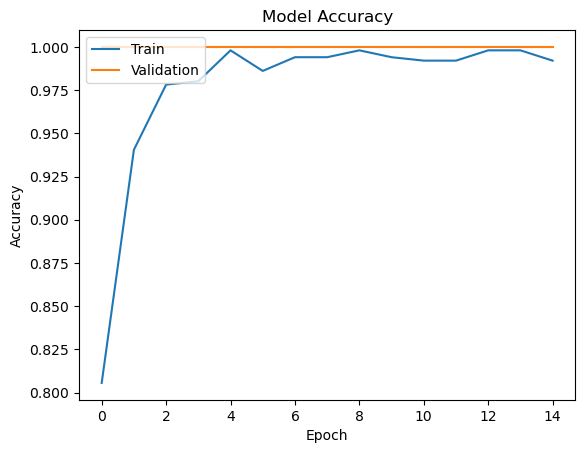

In [145]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [146]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [147]:
model_vgg_train_perf = model_performance_classification(model_vgg, X_train_vgg,y_train_enc, dataset='Training')

print("Train performance metrics")
print(model_vgg_train_perf)


print("Validation performance metrics")
model_vgg_val_perf = model_performance_classification(model_vgg, X_val_vgg, y_val_enc, dataset='Validation')
print(model_vgg_val_perf)

print("Test performance metrics")
model_vgg_test_perf = model_performance_classification(model_vgg, X_test_vgg, y_test_enc, dataset='Testing')
print(model_vgg_test_perf)

lst_vgg= []
lst_vgg.append(model_vgg_train_perf)   
lst_vgg.append(model_vgg_val_perf)
lst_vgg.append(model_vgg_test_perf)
md_table = generate_table_for_md(pd.concat(lst_vgg, ignore_index=True))
print(md_table)

252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step
Train performance metrics
    Dataset  Accuracy  Recall  Precision  F1 Score
0  Training       1.0     1.0        1.0       1.0
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step


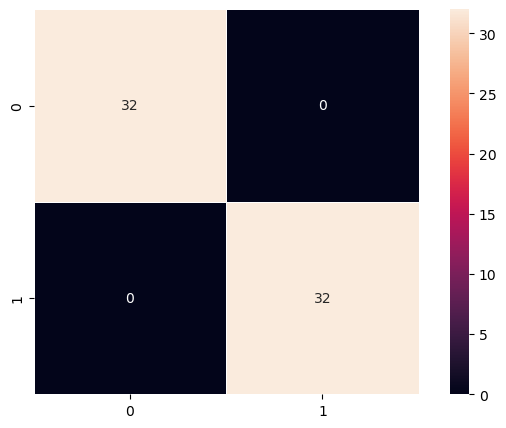

In [148]:
plot_confusion_matrix(model_vgg, X_test_vgg, y_test_enc)

Based on the model below is the performance for the VGG model 

| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |

So Based on the above it can see the model is doing better in terms of all three Training, Validation and Testing Set.

Based on the above confusion matrix we can see that the Model is able  to predict all the Helmet/no-Helmet with 100% efficiency.

This model is better in terms of training and its like training for specific knowledge base when the model is already have generic knowledge

## [**Model 4: VGG16 + FFNN**](#model-4-vgg16--ffnn)  

In [149]:
def clear_tf_session():
    """
    Function to clear the tensorflow session
    """
    tf.keras.backend.clear_session()

In [150]:
def build_vgg_fnn_model(input_shape=(200, 200, 3)):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model

    inputs = layers.Input(shape=input_shape) # Input layer
    model = Sequential() # Initializing the Sequential model
    model.add(base_model) # Adding the base model
    model.add(GlobalAveragePooling2D()) # Adding Global Average Pooling layer
 
 

    #FFN layers
    model.add(Dense(512, activation='relu')) # Adding fully connected layer
    model.add(Dropout(0.5)) # Adding Dropout layer to prevent overfitting
    model.add(Dense(128, activation='relu')) # Adding another fully connected layer
    model.add(Dropout(0.3)) # Adding Dropout layer to prevent overfitting
    model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compiling the model
    return model, base_model

In [151]:
model_vgg_ffnn, base_vgg_ffnn = build_vgg_fnn_model(input_shape=X_train_vgg.shape[1:])
model_vgg_ffnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,043,137 (57.39 MB)

 Trainable params: 328,449 (1.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Here we have VGG with Fully connected layers. So the model looks like below
- VGG16
- Global Average Pooling
- Dense Layer
- Dropout
- Dense layer
- Dropout 
- Dense Output


Here total parameters are 15,043,137 and out of which we have 14,714,688 parameters as non-trainable and only 328,449 as trainable parameters. Again its very less parameters that we need to train which will be more computationly efficient.

In [152]:
clear_tf_session()

In [153]:
model_vgg_ffnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cb_vgg_ffnn = [
    callbacks.ModelCheckpoint('vgg16_ffnn_best.keras', save_best_only=True,
                              monitor='val_accuracy', mode='max'),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7)
]


In [154]:
history_vgg_ffnn = model_vgg_ffnn.fit(
    X_train_vgg, y_train_enc,
    validation_data=(X_val_vgg, y_val_enc),
    epochs=15,
    batch_size=2,
    callbacks=cb_vgg_ffnn,
    verbose=2
)


Epoch 1/15
252/252 - 16s - 62ms/step - accuracy: 0.9067 - loss: 0.3410 - val_accuracy: 1.0000 - val_loss: 0.0042 - learning_rate: 1.0000e-04
Epoch 2/15
252/252 - 10s - 39ms/step - accuracy: 0.9861 - loss: 0.0372 - val_accuracy: 1.0000 - val_loss: 4.9586e-04 - learning_rate: 1.0000e-04
Epoch 3/15
252/252 - 10s - 39ms/step - accuracy: 0.9921 - loss: 0.0295 - val_accuracy: 1.0000 - val_loss: 3.0658e-04 - learning_rate: 1.0000e-04
Epoch 4/15
252/252 - 10s - 40ms/step - accuracy: 0.9960 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 1.5407e-04 - learning_rate: 1.0000e-04
Epoch 5/15
252/252 - 10s - 39ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 9.0798e-05 - learning_rate: 1.0000e-04
Epoch 6/15
252/252 - 10s - 39ms/step - accuracy: 0.9980 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 6.6039e-05 - learning_rate: 1.0000e-04
Epoch 7/15
252/252 - 10s - 40ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 4.6394e-05 - learning_rate: 

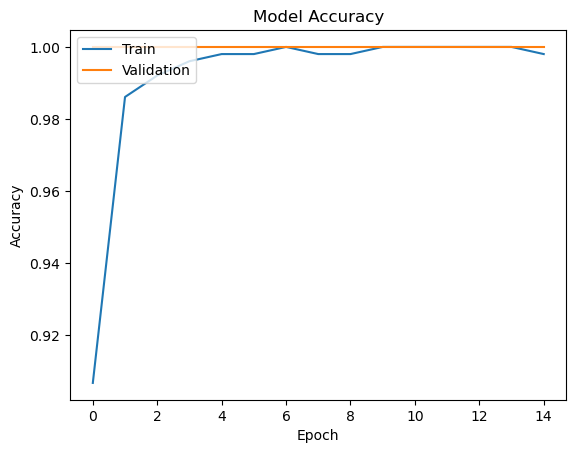

In [155]:
plt.plot(history_vgg_ffnn.history['accuracy'])
plt.plot(history_vgg_ffnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

We can see after each epoch the training and validation are matching properly and it becomes almost same, which suggest better generalization and no overfitting.

In [156]:
model_vgg_ffnn_train_perf = model_performance_classification(model_vgg_ffnn, X_train_vgg,y_train_enc, dataset='Training')

print("Train performance metrics")
print(model_vgg_ffnn_train_perf)


print("Validation performance metrics")
model_vgg_ffnn_val_perf = model_performance_classification(model_vgg_ffnn, X_val_vgg, y_val_enc,dataset='Validation')
print(model_vgg_ffnn_val_perf)

print("Test performance metrics")
model_vgg_ffnn_test_perf = model_performance_classification(model_vgg_ffnn, X_test_vgg, y_test_enc,dataset='Testing')
print(model_vgg_ffnn_test_perf)


lst_vgg_ffnn = []
lst_vgg_ffnn.append(model_vgg_ffnn_train_perf)
lst_vgg_ffnn.append(model_vgg_ffnn_val_perf)
lst_vgg_ffnn.append(model_vgg_ffnn_test_perf)

md_table = generate_table_for_md(pd.concat(lst_vgg_ffnn, ignore_index=True))
print(md_table)



252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step
Train performance metrics
    Dataset  Accuracy  Recall  Precision  F1 Score
0  Training       1.0     1.0        1.0       1.0
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step


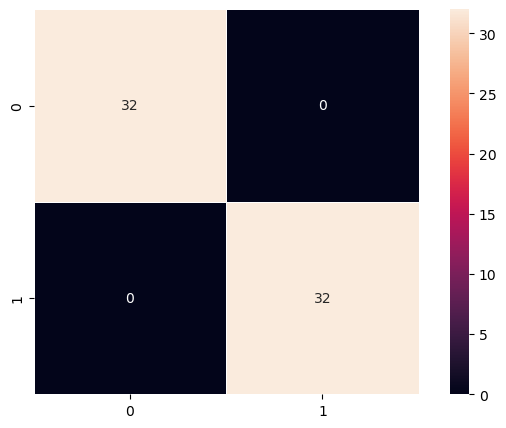

In [157]:
plot_confusion_matrix(model_vgg_ffnn, X_test_vgg, y_test_enc)

Again this model has performed exceptionally as shown in below

| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |


Also based on above confusion matrix we can see it has correctly identified the Helmet/No-Helmet pictures.

This model is better as we again have less parameters to train and we can work on training the parameters which is specific to the task rather than entire model from scratch. 

## [**Model 5: VGG16 + Data Augmentation**](#model-5-vgg16--data-augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

Modularizing the below sections so that we can use both VGG and VGG + FNN with Data Augmentation

In [158]:
def plot_confusion_matrix_for_keras(model, data_gen):

    y_true = data_gen.y

    # get predictions
    y_pred_prob = model.predict(data_gen)
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    # compute matrix
    cm = confusion_matrix(y_true, y_pred)

    # plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


In [159]:
def get_generators(X_train, y_train, X_val, y_val, X_test, y_test, use_aug=False, batch_size=2,shuffle=False, specific_return_gen=None):

    """
        Function to create data generators for training, validation, and testing datasets

    """

    if use_aug:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=180,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
        )
    else:
        train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input) 
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=shuffle) # Training generator
    val_gen = val_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False) # Validation generator 
    test_gen = test_datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False) # Testing generator
    
    if specific_return_gen =='train':
        return train_gen
    else:
        return train_gen, val_gen, test_gen

In [160]:
def build_vgg_model(input_shape, model_type='vgg16'):

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape) # Using VGG16 as base model
    base_model.trainable = False  # Freeze the base model

    input_layer = layers.Input(shape=input_shape) # Input layer
    x = base_model(input_layer, training=False) # Passing input through base model
    x = GlobalAveragePooling2D()(x) # Global Average Pooling layer

    if model_type=='vgg16':
        x = layers.Dropout(0.5)(x) # Dropout layer
        output_layer = layers.Dense(1, activation='sigmoid')(x)  # Output layer for binary classification
    elif model_type=='vgg16_fnn':
        x = layers.Dense(512, activation='relu')(x) # Fully connected layer
        x = layers.Dropout(0.5)(x) # Dropout layer
        x = layers.Dense(128, activation='relu')(x) # Another fully connected layer
        x = layers.Dropout(0.3)(x) # Dropout layer
        output_layer = layers.Dense(1, activation='sigmoid')(x)  # Output layer for binary classification
    else:
        raise ValueError("Invalid model_type. Choose 'vgg16' or 'vgg16_fnn'.")
    

    model = models.Model(input_layer, output_layer, name = model_type)
    print('retuning model')
    return model, base_model

In [161]:
def get_vgg_training_setup(model_type = 'vgg16', batch_size=2, epochs=15):
    model, base_model = build_vgg_model(input_shape=(200, 200, 3), model_type=model_type)

    model.compile(optimizer = optimizers.Adam(learning_rate=1e-4), loss=losses.binary_crossentropy, metrics=['accuracy'])

    cb = [
        callbacks.ModelCheckpoint(f'{model_type}_aug_best.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]

    return model,cb

In [162]:
clear_tf_session()

In [163]:
train_gen, val_gen, test_gen = get_generators(X_train_rgb_original, y_train_enc,X_val_rgb_original, y_val_enc, X_test_rgb_original, y_test_enc, use_aug=True,  batch_size=2)

#Need to create it as for the post validation we need to use the training generator without shuffling otherwise the order of images will be different and the evaluation will not be correct
train_gen_post_validation = get_generators(X_train_rgb_original, y_train_enc,X_val_rgb_original, y_val_enc, X_test_rgb_original, y_test_enc, use_aug=True,  batch_size=2, shuffle = False,specific_return_gen='train')

In [164]:
print(train_gen_post_validation)

In [165]:
print("Size of X_train_vgg:", X_train_vgg.shape)
print("size of train_gen:", X_train_vgg.shape[0])

Size of X_train_vgg: (504, 200, 200, 3)
size of train_gen: 504


In [166]:
clear_tf_session()

In [167]:


model_vgg_with_data_aug,cb = get_vgg_training_setup(model_type='vgg16')

history_vgg_aug = model_vgg_with_data_aug.fit(
    train_gen, validation_data=val_gen,
    epochs=15, callbacks=cb, verbose=2,
    batch_size=2
)

retuning model
Epoch 1/15
252/252 - 15s - 58ms/step - accuracy: 0.3234 - loss: 4.5964 - val_accuracy: 0.1905 - val_loss: 2.6621 - learning_rate: 1.0000e-04
Epoch 2/15
252/252 - 10s - 41ms/step - accuracy: 0.4405 - loss: 2.8884 - val_accuracy: 0.5556 - val_loss: 1.3544 - learning_rate: 1.0000e-04
Epoch 3/15
252/252 - 11s - 42ms/step - accuracy: 0.5913 - loss: 1.8715 - val_accuracy: 0.6667 - val_loss: 0.7399 - learning_rate: 1.0000e-04
Epoch 4/15
252/252 - 10s - 41ms/step - accuracy: 0.6687 - loss: 1.2734 - val_accuracy: 0.8254 - val_loss: 0.4051 - learning_rate: 1.0000e-04
Epoch 5/15
252/252 - 10s - 41ms/step - accuracy: 0.7857 - loss: 0.9155 - val_accuracy: 0.8730 - val_loss: 0.2225 - learning_rate: 1.0000e-04
Epoch 6/15
252/252 - 11s - 43ms/step - accuracy: 0.7738 - loss: 0.7370 - val_accuracy: 0.9206 - val_loss: 0.1348 - learning_rate: 1.0000e-04
Epoch 7/15
252/252 - 10s - 41ms/step - accuracy: 0.8571 - loss: 0.4564 - val_accuracy: 0.9683 - val_loss: 0.1078 - learning_rate: 1.0000e-0

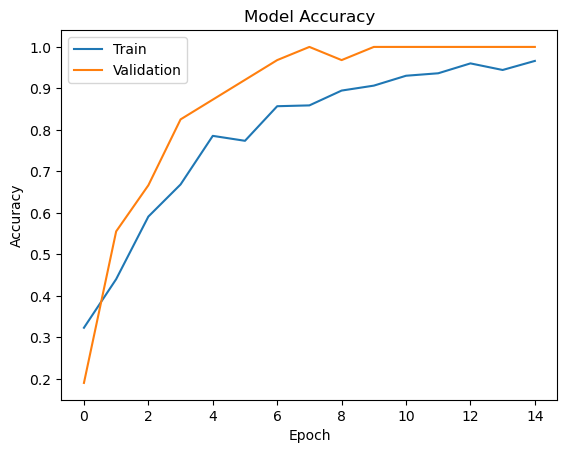

In [168]:
plt.plot(history_vgg_aug.history['accuracy'])
plt.plot(history_vgg_aug.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

We can see after each epoch training and validation are almost coming together which means that model is generalizing well.

In [169]:
def model_performance_classification_generator(model, data_gen, dataset):
    """
    Function to compute different metrics to check classification model performance using data generator

    model: classifier
    data_gen: data generator
    dataset: name of the dataset (e.g., 'Training', 'Validation', 'Testing')
    """

    # Get true labels from the generator
    y_true = data_gen.y

    # Get predictions from the model
    y_pred_prob = model.predict(data_gen)
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    acc = accuracy_score(y_true, y_pred)  # to compute Accuracy
    recall = recall_score(y_true, y_pred, average='weighted')  # to compute Recall
    precision = precision_score(y_true, y_pred, average='weighted')  # to compute Precision
    f1 = f1_score(y_true, y_pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Dataset": dataset,"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [170]:
model_vgg_aug_train_perf = model_performance_classification_generator(model_vgg_with_data_aug, train_gen_post_validation, dataset='Training')

print("Train performance metrics")
print(model_vgg_aug_train_perf)


print("Validation performance metrics")
model_vgg_aug_val_perf = model_performance_classification_generator(model_vgg_with_data_aug, val_gen,dataset='Validation')
print(model_vgg_aug_val_perf)

print("Test performance metrics")
model_vgg_aug_test_perf = model_performance_classification_generator(model_vgg_with_data_aug, test_gen,dataset='Testing')
print(model_vgg_aug_test_perf)


lst_vgg_aug = []
lst_vgg_aug.append(model_vgg_aug_train_perf)
lst_vgg_aug.append(model_vgg_aug_val_perf)
lst_vgg_aug.append(model_vgg_aug_test_perf)

md_table = generate_table_for_md(pd.concat(lst_vgg_aug, ignore_index=True))
print(md_table)



252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step
Train performance metrics
    Dataset  Accuracy    Recall  Precision  F1 Score
0  Training  0.998016  0.998016   0.998024  0.998016
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.998016 | 0.998016 |    0.998024 |   0.998016 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


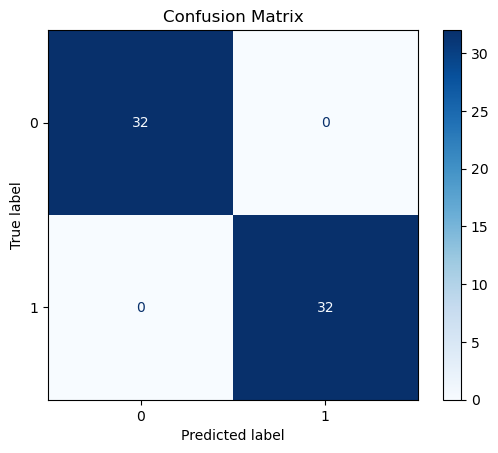

In [171]:
plot_confusion_matrix_for_keras(model_vgg_with_data_aug, test_gen)

So based on above we can see the model has performed well
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |   0.998016 | 0.998016 |    0.998024 |   0.998016 |
| Validation |   1        | 1        |    1        |   1        |
| Testing    |   1        | 1        |    1        |   1        |

The performance was less on training dataset ~99.8% but its 100% on Validation and 100% on the test dataset. As the training was done on the augmented/distorted images it may be hard for the model to get the good performance, but once the images are proper it was able to identify properly. So it seems that model is generalizing better.

In [172]:
clear_tf_session()

## [**Model 6: VGG16 + FFNN + Data Augmentation (Final Model)**](#model-6-vgg16--ffnn--data-augmentation-final-model) 

In [173]:
model_vgg_fnn_with_data_aug,cb = get_vgg_training_setup(model_type='vgg16_fnn')

history_vgg_fnn_aug = model_vgg_fnn_with_data_aug.fit(
    train_gen, validation_data=val_gen,
    epochs=15, callbacks=cb, verbose=2,
    batch_size=2
)

retuning model
Epoch 1/15
252/252 - 15s - 61ms/step - accuracy: 0.8750 - loss: 0.3842 - val_accuracy: 0.9841 - val_loss: 0.0231 - learning_rate: 1.0000e-04
Epoch 2/15
252/252 - 11s - 42ms/step - accuracy: 0.9802 - loss: 0.0662 - val_accuracy: 1.0000 - val_loss: 0.0111 - learning_rate: 1.0000e-04
Epoch 3/15
252/252 - 10s - 40ms/step - accuracy: 0.9782 - loss: 0.0471 - val_accuracy: 1.0000 - val_loss: 0.0059 - learning_rate: 1.0000e-04
Epoch 4/15
252/252 - 10s - 40ms/step - accuracy: 0.9960 - loss: 0.0251 - val_accuracy: 1.0000 - val_loss: 0.0024 - learning_rate: 1.0000e-04
Epoch 5/15
252/252 - 10s - 41ms/step - accuracy: 0.9980 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 3.4691e-04 - learning_rate: 1.0000e-04
Epoch 6/15
252/252 - 10s - 40ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 1.0000e-04
Epoch 7/15
252/252 - 10s - 40ms/step - accuracy: 0.9960 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 4.6563e-05 - learning_rate: 1

In [174]:
model_vgg_fnn_with_data_aug.summary()

Model: "vgg16_fnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,700,037 (59.89 MB)

 Trainable params: 328,449 (1.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 656,900 (2.51 MB)

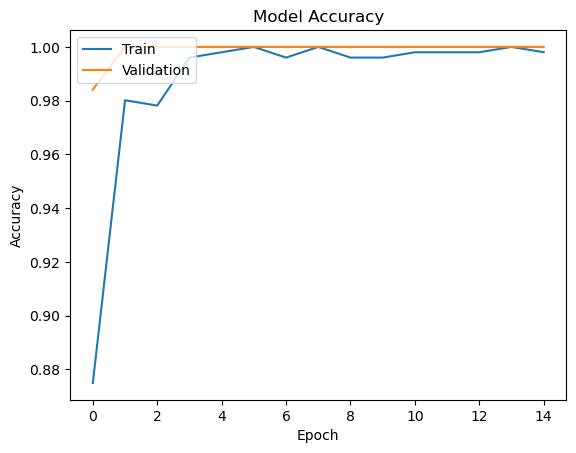

In [175]:
plt.plot(history_vgg_fnn_aug.history['accuracy'])
plt.plot(history_vgg_fnn_aug.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Based on above graph we can see how perfectly training and validation set are being mapped.

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


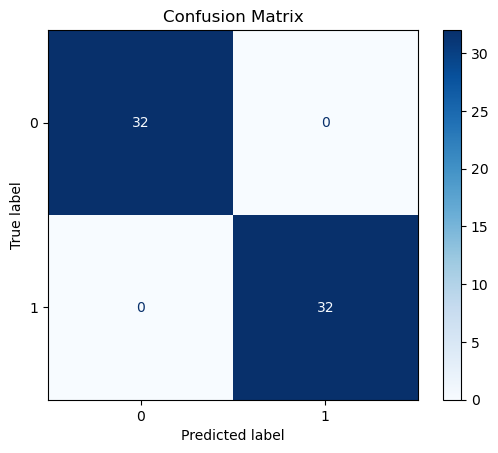

In [176]:
plot_confusion_matrix_for_keras(model_vgg_fnn_with_data_aug, test_gen)

In [177]:
model_vgg_ffnn_aug_train_perf = model_performance_classification_generator(model_vgg_fnn_with_data_aug, train_gen_post_validation, dataset='Training')

print("Train performance metrics")
print(model_vgg_ffnn_aug_train_perf)


print("Validation performance metrics")
model_vgg_ffnn_aug_val_perf = model_performance_classification_generator(model_vgg_fnn_with_data_aug, val_gen,dataset='Validation')
print(model_vgg_ffnn_aug_val_perf)

print("Test performance metrics")
model_vgg_ffnn_test_perf = model_performance_classification_generator(model_vgg_fnn_with_data_aug, test_gen,dataset='Testing')
print(model_vgg_ffnn_test_perf)


lst_vgg_ffnn_aug = []
lst_vgg_ffnn_aug.append(model_vgg_ffnn_aug_train_perf)
lst_vgg_ffnn_aug.append(model_vgg_ffnn_aug_val_perf)
lst_vgg_ffnn_aug.append(model_vgg_ffnn_test_perf)

md_table = generate_table_for_md(pd.concat(lst_vgg_ffnn_aug, ignore_index=True))
print(md_table)



252/252 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step
Train performance metrics
    Dataset  Accuracy  Recall  Precision  F1 Score
0  Training       1.0     1.0        1.0       1.0
Validation performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
      Dataset  Accuracy  Recall  Precision  F1 Score
0  Validation       1.0     1.0        1.0       1.0
Test performance metrics
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
   Dataset  Accuracy  Recall  Precision  F1 Score
0  Testing       1.0     1.0        1.0       1.0
| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |


Based on the above performance of the model is at par

| Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:-----------|-----------:|---------:|------------:|-----------:|
| Training   |          1 |        1 |           1 |          1 |
| Validation |          1 |        1 |           1 |          1 |
| Testing    |          1 |        1 |           1 |          1 |

So we are getting 100% performance on all the dataset. So it's an ideal model for determining the Helmet/No-Helmet images.

## Visualization of image from the Model 

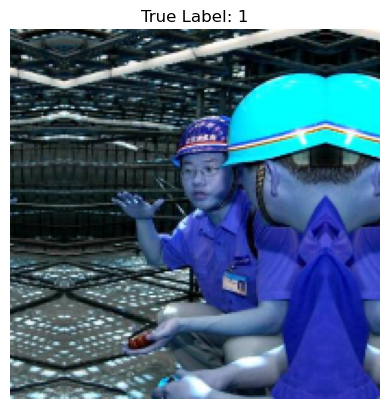

Predicting on the random test image using different models:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Grayscale CNN Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
RGB CNN Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
VGG16 Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
VGG16 + FNN Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
VGG16 + Data Augmentation Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
VGG16 + FNN + Data Augmentation Prediction: 1 (Probability: 1.0000)


In [178]:
#Lets pick one random image from the test set and see how different models predict on it
random_index = random.randint(0, X_test_rgb_original.shape[0]-1)
test_image_rgb = X_test_rgb_original[random_index]
test_image_gray = X_test_gray[random_index] [..., np.newaxis]  # Adding channel dimension   
plt.imshow(X_test_rgb_original[random_index])
plt.title(f"True Label: {y_test.iloc[random_index]}")
plt.axis('off')
plt.show() 
print("Predicting on the random test image using different models:")
def predict_on_image(model, image, model_name):
    """
    Function to predict on a single image using a given model

    model: trained model
    image: input image
    model_name: name of the model
    """
    image_expanded = np.expand_dims(image, axis=0)  # Expanding dimensions to match model input
    prediction_prob = model.predict(image_expanded)[0][0]
    prediction = 1 if prediction_prob > 0.5 else 0
    print(f"{model_name} Prediction: {prediction} (Probability: {prediction_prob:.4f})")


predict_on_image(model_gray, test_image_gray, "Grayscale CNN")
predict_on_image(model_rgb, test_image_rgb, "RGB CNN")
predict_on_image(model_vgg, test_image_rgb, "VGG16")
predict_on_image(model_vgg_ffnn, test_image_rgb, "VGG16 + FNN")
predict_on_image(model_vgg_with_data_aug, test_image_rgb, "VGG16 + Data Augmentation")
predict_on_image(model_vgg_fnn_with_data_aug, test_image_rgb, "VGG16 + FNN + Data Augmentation")


So based on the above result we can see all the models has predicted the Image to be a Helmet Image correctly.
|Model|Prediction|
|---|---|
|Grayscale CNN Prediction| 1 |
|RGB CNN|1|
|VGG16|1|
|VGG16+ FNN|1|
|VGG16+Data Augmentation|1|
|VGG16+FNN+Data Augmentation|1|





## [**Model Performance Comparison**](#model-performance-comparison)

In [179]:
for df in lst_gray:
    df['Model'] = 'Grayscale CNN'

for df in lst_rgb:
    df['Model'] = 'RGB CNN'

for df in lst_vgg:
    df['Model'] = 'VGG16'

for df in lst_vgg_ffnn:
    df['Model'] = 'VGG16 + FNN'

for df in lst_vgg_aug:
    df['Model'] = 'VGG16 + Data Augmentation'

for df in lst_vgg_ffnn_aug:
    df['Model'] = 'VGG16 + FNN + Data Augmentation'

final_results = pd.concat(lst_gray + lst_rgb + lst_vgg + lst_vgg_ffnn + lst_vgg_aug + lst_vgg_ffnn_aug, ignore_index=True)
final_results = final_results[['Model', 'Dataset', 'Accuracy', 'Recall', 'Precision', 'F1 Score']]

md_table = generate_table_for_md(final_results)
print(md_table)

| Model                           | Dataset    |   Accuracy |   Recall |   Precision |   F1 Score |
|:--------------------------------|:-----------|-----------:|---------:|------------:|-----------:|
| Grayscale CNN                   | Training   |   0.998016 | 0.998016 |    0.998024 |   0.998016 |
| Grayscale CNN                   | Validation |   1        | 1        |    1        |   1        |
| Grayscale CNN                   | Testing    |   1        | 1        |    1        |   1        |
| RGB CNN                         | Training   |   0.994048 | 0.994048 |    0.994055 |   0.994047 |
| RGB CNN                         | Validation |   1        | 1        |    1        |   1        |
| RGB CNN                         | Testing    |   1        | 1        |    1        |   1        |
| VGG16                           | Training   |   1        | 1        |    1        |   1        |
| VGG16                           | Validation |   1        | 1        |    1        |   1        |


In [180]:
wide = final_results.pivot_table(
    index='Model',
    columns='Dataset',
    values=['Accuracy', 'Recall', 'Precision', 'F1 Score']
)

wide.columns = [
    f"{dataset.lower()}_{metric.lower().replace(' ', '_')}"
    for metric, dataset in wide.columns.to_flat_index()
]


wide.reset_index(inplace=True)

cols = ['Model'] + [c for c in wide.columns if c != 'Model']
wide = wide[cols]

In [181]:
md_table = generate_table_for_md(wide)
print(md_table)

| Model                           |   testing_accuracy |   training_accuracy |   validation_accuracy |   testing_f1_score |   training_f1_score |   validation_f1_score |   testing_precision |   training_precision |   validation_precision |   testing_recall |   training_recall |   validation_recall |
|:--------------------------------|-------------------:|--------------------:|----------------------:|-------------------:|--------------------:|----------------------:|--------------------:|---------------------:|-----------------------:|-----------------:|------------------:|--------------------:|
| Grayscale CNN                   |                  1 |            0.998016 |                     1 |                  1 |            0.998016 |                     1 |                   1 |             0.998024 |                      1 |                1 |          0.998016 |                   1 |
| RGB CNN                         |                  1 |            0.994048 |                   

So based on all the models that has been trained below is how the performance looks like

| Model   |  testing_accuracy |  training_accuracy |  validation_accuracy |  testing_f1_score |  training_f1_score |  validation_f1_score |  testing_precision |  training_precision |  validation_precision |  testing_recall |  training_recall |  validation_recall |Comments|
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Grayscale CNN | 1 | 0.998016 |  1 | 1  | 0.998016 |  1 | 1  |  0.998024 |   1 |   1 |   0.998016 | 1 |Perfoms well but it may lose benefit of colors|
| RGB CNN  |  1 | 0.994048 |  1 | 1 | 0.994047 |  1 | 1 |  0.994055 |   1 | 1 |   0.994048 | 1 |1 |Almost same as performance as Grayscale but its still a CNN|
| VGG16 (Trasfer Learning)  | 1 | 1  |  1 | 1  | 1  |  1 | 1  |  1  |   1 |   1 |   1  | 1 |As Imagenet it pretrained model its uses pretrained features, so it will provide a good performance|
| VGG16 + Data Augmentation | 1 | 0.998016 |  1 | 1  | 0.998016 |  1 | 1  |  0.998024 |   1 |   1 |   0.998016 | 1 |Its better than pure Pre-trained model as data is augmented with different Modified Images| 
| VGG16 + FNN  | 1 | 1  |  1 | 1  | 1  |  1 | 1  |  1  |   1 |   1 |   1  | 1 |Add more generalized layers which gives better performance|
| VGG16 + FNN + Data Augmentation | 1 | 1  |  1 | 1  | 1  |  1 | 1  |  1  |   1 |   1 |   1  | 1 |Best in terms of all the benefits of pre-trained model with modified image learning and a convolutional layer giving more real-world scenarios|



All the models have performed really well on the dataset. But based on the criticality of the Helmet/No-Helmet situation. Since this is critical for safety, it is important to have a highly accurate model.


🔭 **Observation**

- All models achieve almost perfect performance and all three datasets (Training, Validation and Test)
- This shows that the dataset is very clean and helmet vs no-helmet is a very easily distinguishable problem
- But such consistent performance may also be due to fact
    - The dataset is relatively small and may not have all the images which can occur
    - Transfer learning is highly optimized and may lead to overfitting
- Among all the models *VGG16 + FNN + Data Augmentation* is expected to perform better in the real-world scenarios as
    - Augmentation helps the model learn from different variations
    - It can help in creating those scenarios which may not be always available e.g. Stretched images, Worker location with respect to camera, height and others
    - It can also help in creating more scenarios where there are shadows and all the images are not available




## [**Final Model Selection**](#final-model-selection)

🏆**Final Model Selection**

>

Although all the models performed equally well,

The final recommended model is **VGG16+FNN+Data Augmentation**

>

Reason for selecting the model
- The combination of pre-trained model VGG16 features, additional dense layer and augmented training data ensures that model performs well in the real-world scenarios.
- The FNN layer helps the model learn patterns beyond what the pre-trained provides.
- The images used are RGB image which is better for distinguishing whether a person is wearing a helmet or not.
- The Data is Augmented which will enhance the probability of getting the actual Helmet/No Helmet situation.
- This model is computation efficient and provides a robust solution in the real-life scenarios ( Total params: 15,700,037, Trainable params: 328,449, Non-trainable params: 14,714,688, Optimizer params: 656,900). So we can see that only ~328k training parameters need to be trained out of 15M parameters.

## Test Performance

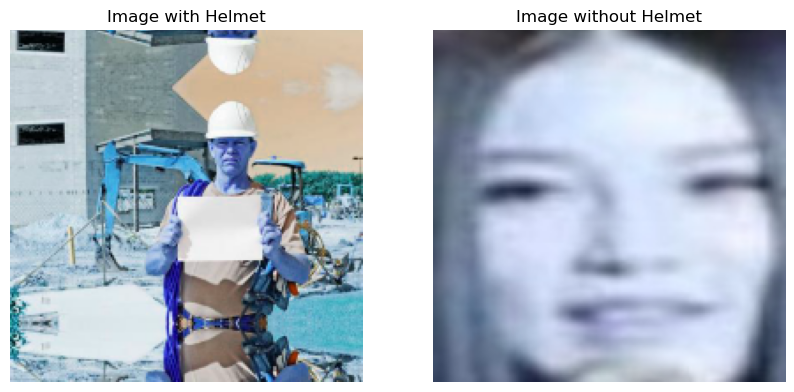

Predictions using VGG16 + FNN + Data Augmentation model:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Image with Helmet Prediction: 1 (Probability: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Image without Helmet Prediction: 0 (Probability: 0.0000)


In [183]:
#Getting a image with a Helmet and without a Helmet from the test set
helmet_index = np.where(y_test_enc==1)[0][0]
no_helmet_index = np.where(y_test_enc==0)[0][0]
image_with_helmet = X_test_rgb_original[helmet_index]
image_without_helmet = X_test_rgb_original[no_helmet_index]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_with_helmet)
plt.title("Image with Helmet")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(image_without_helmet)
plt.title("Image without Helmet")
plt.axis('off')
plt.show()

#Predicting on the image with a Helmet and without a Helmet using the best model (VGG16 + FNN + Data Augmentation)
print("Predictions using VGG16 + FNN + Data Augmentation model:")
predict_on_image(model_vgg_fnn_with_data_aug, image_with_helmet, "Image with Helmet")
predict_on_image(model_vgg_fnn_with_data_aug, image_without_helmet, "Image without Helmet")

Based on the above we can see that Model has predicted perfectly the Helmet vs No-Helmet images.

Left image has person with Helmet and the Model predicted Probability -  1

Right image has person not wearing Helmet and the Model predicted Probability -  0

## [**Actionable Insights & Recommendations**](#actionable-insights--recommendations)


**Actionable Insights & Recommendations**

1. Helmet vs. No-Helmet is an easily distinguishable problem 

    All models reached 100% accuracy, showing that the dataset is well-structured and its easy to distinguish between the helmet vs non-helmet.

2. Transfer Learning improves performance
    
    Using VGG16 significantly reduced training parameters which reduces the time for training the model. It also helps in improving feature extraction quality compared to custom CNNs.

3. Augmentation helps in providing real-world performance
    
    Since real workplace images can change depending upon lighting, noise, angle, and visibility, augmentation makes the model more stable. Make more data augmentation techniques to derive more images which will make model more prepared to common world problems.

4. The addition of FFNN layers enhances model performance
    
    Adding more fully connected layer helps in identifying fine-grain differences between workers wearing a helmet or not.

5. Evaluation of high accuracy models with real-world scenarios
    
    As this model is going to be used on the real-world and wearing a helmet is essential for safety this model needs to be verified, even though it performs better in the given dataset but practical validation needs to happen to ensure safety measures.

6. Training with more images

    Need to get more images with different weather conditions, shadows and different angles so that the model can have more training data.


7. Monitor the drift

    Make sure to monitor the drift as more and more images are coming in case the performance is below certain threshold, re-train the model.


**Business Recommendations for SafeGuard Corp**

1. Deploy the VGG16 + FNN + Data Augmentation Model
    
    This model is the best suited for deployment due to the generalization.

2. Run a pilot program before full-scale rollout
    As this is safety measure, create a pilot implementation using CCTV for few places. Check for below measures to ensure right output
    
    Measure:

    - Accuracy

    - False positives (Predicting No helmets even though helmet is there)

    - False negatives (Missing helmet)

3. Continuous improvement
    
    Identify those images where there is wrong identification and based on that train the model for those changes. This change can happen due to lighting effect, weather effect, rain, dust etc. Retrain the model periodically so that it can adopt to changing environment.

4. Create an alerting system
    
    When a worker is not wearing the helmet, create an alert and send the notification which can also be logged. This will ensure two things
        
        a. Workers will always wear helmets
        
        b. Look for mis-identified occurences which can later help to make the model better


This allows SafeGuard Corp to transition toward a comprehensive AI-driven Safety Intelligence System.

## [**Conclusion**](#conclusion)


In this project, we have successfully developed an automated helmet detection model which will help in improving safety compliance at workplace. We have built multiple models with grayscale CNNs, RGB CNNs, VGG16, VGG16 with fully connected network, and augmented variants. We have tested each approach to see how it performed in terms of accuracy, generalization, and robustness.

Among all the architectures it's evident that transfer learning provides a better performance as compared to traditional CNN as it uses pre-trained features extractors. After comparing all the models *VGG16 + FNN + Data Augmentation* has been selected as the final model due to its ability to generalize, higher robustness and able to perform in real-world scenarios with changing conditions. This has been depicted in Training, Validation and Testing dataset.

Based on the project it seems that helmet vs non-helmet classification is easily separable problem. But this test has been done on the provided dataset. In real-world scenario we need a model that can classify in various different setttings or environments. The selected model meets the requirement and is suitable for deployment in industrial settings where automated security monitoring can reduce risks, improve compliance and promotes proactive safety measures.

Overall, this project demonstrates how deep learning along with transfer learning can be applied effectively to solve critical challenges. With continuously collecting data, retraining the model on regular basis and integration with the CCTV and creating alerts will help in creating a more safer work environment.